#### Imporrt Libraries

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#### Load Data

In [5]:
df = pd.read_csv("C:\\Users\\ACER\\Documents\\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\\data\\MCU_Dataset.csv")

df.head()

,title,type,release_year,mcu_phase_number,imdb_rating,rt_tomato_meter,rt_audience_score,production_budget,domestic_box_office,international_box_office,...,director,profit,roi,decade,success_category,success_encoded,success_score,imdb_scaled,audience_scaled,roi_scaled
0,iron man,Movie,2008,1,7.9,94,91,140000000,319034126,266762121,...,Jon Favreau,445796247,318.425891,2000,Hit,2,73.291607,0.871795,0.893939,0.386721
1,the incredible hulk,Movie,2008,1,6.6,67,70,140000000,134806913,128620638,...,Louis Leterrier,123427551,88.162536,2000,Hit,2,42.603623,0.538462,0.575758,0.126414
2,iron man 2,Movie,2010,1,6.9,72,71,200000000,312433331,311500000,...,Jon Favreau,423933331,211.966666,2010,Hit,2,50.333809,0.615385,0.590909,0.266372
3,thor,Movie,2011,1,7.0,77,76,150000000,181030624,268295994,...,Kenneth Brangh,299326618,199.551079,2010,Hit,2,53.211113,0.641026,0.666667,0.252336
4,captain america the first avenger,Movie,2011,1,6.9,79,75,140000000,176654505,193915269,...,Joe Johnston,230569774,164.692696,2010,Hit,2,50.548732,0.615385,0.651515,0.212930


Features

In [6]:
cluster_df = df[
[
    "imdb_rating",
    "rt_audience_score",
    "production_budget",
    "worldwide_box_office",
    "roi"
]
]

#### Scaling

In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_df
)

#### Elbow Method

In [8]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(
        kmeans.inertia_
    )

#### Plot Elbow

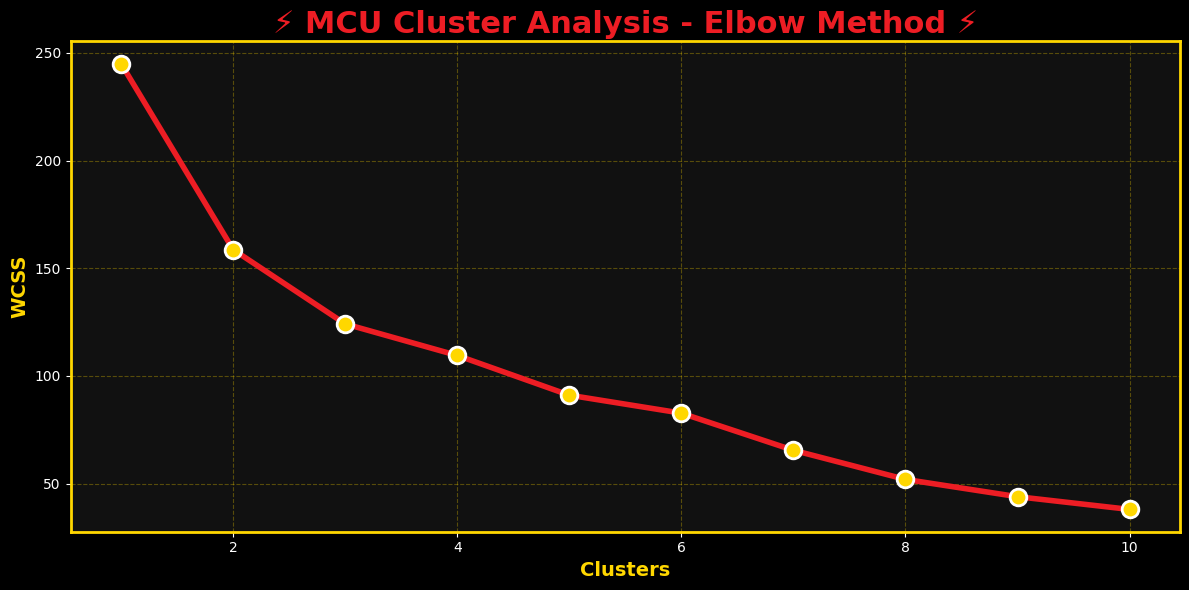

In [11]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

fig.patch.set_facecolor("black")
ax.set_facecolor("#111111")

ax.plot(
    range(1,11),
    wcss,
    color="#ED1D24",
    linewidth=4,
    marker="o",
    markersize=12,
    markerfacecolor="gold",
    markeredgewidth=2,
    markeredgecolor="white"
)

ax.set_title(
    "⚡ MCU Cluster Analysis - Elbow Method ⚡",
    fontsize=22,
    color="#ED1D24",
    weight="bold"
)

ax.set_xlabel(
    "Clusters",
    fontsize=14,
    color="gold",
    weight="bold"
)

ax.set_ylabel(
    "WCSS",
    fontsize=14,
    color="gold",
    weight="bold"
)

ax.grid(
    linestyle="--",
    alpha=0.3,
    color="gold"
)

for spine in ax.spines.values():
    spine.set_color("gold")
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\visuals\MCU_Cluster_Analysis_Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(
    scaled_data
)

In [14]:
df[
[
"title",
"cluster"
]
].head(40)

,title,cluster
0,iron man,2
1,the incredible hulk,1
2,iron man 2,2
3,thor,2
4,captain america the first avenger,2
5,the avengers,0
6,iron man 3,0
7,thor the dark world,2
8,captain america the winter soldier,2
9,guardians of the galaxy,2


In [15]:
cluster_summary = df.groupby(
    "cluster"
)[
[
    "worldwide_box_office",
    "imdb_rating",
    "roi"
]
].mean()

print(cluster_summary)

         worldwide_box_office  imdb_rating         roi
cluster                                               
0                1.587502e+09     7.740000  579.993737
1                2.013070e+08     5.900000   83.749982
2                4.852950e+08     7.251724  185.894389


In [16]:
cluster_names = {

0:"MCU Legends",

1:"Successful Heroes",

2:"Struggling Titles"

}

df["cluster_name"] = df[
    "cluster"
].map(cluster_names)

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="imdb_rating",
    y="worldwide_box_office",
    hue="cluster_name",
    s=150
)

plt.title("MCU Movie Segmentation")
plt.show()

plt.title(
    "MCU Movie Segmentation"
)

plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x800 with 0 Axes>